In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib  

In [5]:
df = pd.read_csv("../data/processed/clean_data.csv")

In [6]:
X = df[["cpu_scaled", "memory_scaled"]]

In [8]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [9]:
df["anomaly"] = model.predict(X)

In [10]:
print(df["anomaly"].value_counts())

anomaly
 1    2853
-1     151
Name: count, dtype: int64


In [11]:
df[df["anomaly"] == -1].head()

,timeStamp,cpu_scaled,memory_scaled,anomaly
48,2026-02-05 10:50:19.183366,0.036,0.821,-1
51,2026-02-05 10:50:22.207849,0.029,0.819,-1
52,2026-02-05 10:50:23.223071,0.018,0.819,-1
64,2026-02-05 10:50:35.309327,0.010,0.824,-1
66,2026-02-05 10:50:37.326804,0.023,0.824,-1


In [12]:
joblib.dump(model, "../models/anomaly_model.pkl")
print("Model trained")

Model trained


Visualization

In [13]:
import matplotlib.pyplot as plt

normal = df[df['anomaly'] == 1]
anomaly = df[df['anomaly'] == -1]

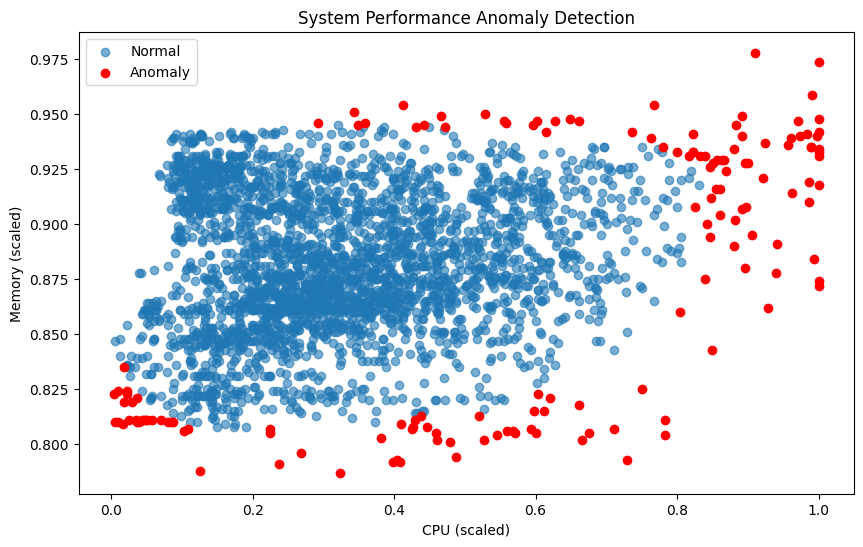

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(
    normal["cpu_scaled"],
    normal["memory_scaled"],
    label="Normal",
    alpha=0.6
)

plt.scatter(
    anomaly["cpu_scaled"],
    anomaly["memory_scaled"],
    label="Anomaly",
    color="red"
)

plt.xlabel("CPU (scaled)")
plt.ylabel("Memory (scaled)")
plt.title("System Performance Anomaly Detection")
plt.legend()
plt.show()

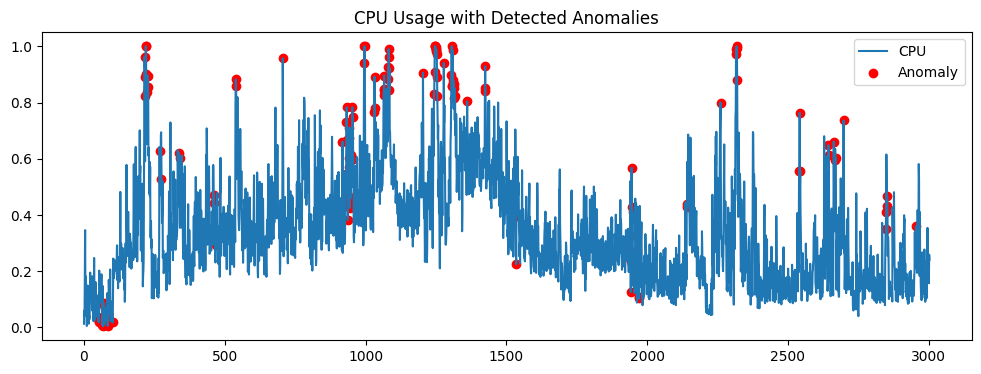

In [15]:
plt.figure(figsize=(12,4))
plt.plot(df["cpu_scaled"], label="CPU")
plt.scatter(
    df.index[df["anomaly"] == -1],
    df["cpu_scaled"][df["anomaly"] == -1],
    color="red",
    label="Anomaly"
)
plt.title("CPU Usage with Detected Anomalies")
plt.legend()
plt.show()
